# Seville fire weather — daily FWI, 1990–2025

**Source.** `cems-fire-historical-v1`, *Fire danger indices historical data from the
Copernicus Emergency Management Service*, hosted on the **CEMS Early Warning Data
Store** (`ewds.climate.copernicus.eu`) — a different portal from the CDS, with a
separate API key. GEFF model forced by ERA5, `system_version=4_1`,
`dataset_type=consolidated_dataset`, `product_type=reanalysis`.

Values are the mean over the 2×2 block of cells nearest 37.25°/37.50° N,
−6.00°/−5.75° E — the same block used for the heat indicators.

Produced by `fetch_seville_fire.py` (`fwi-download` → `fwi-subset`).

### Three things to keep in mind before reading any number here

**1. FWI is a noon-referenced index.** GEFF computes it from local-noon
temperature, relative humidity, wind and 24-h precipitation. Any comparison
against a daily maximum or a 6-hourly mean derived from raw ERA5 is comparing
different quantities, and the mismatch is systematic, not noise.

**2. The moisture codes have long memory, so daily *n* is not the sample size
you have.** The Drought Code has roughly a 52-day time constant and the Build-Up
Index inherits it. Lag-1 autocorrelation of daily FWI here is well above 0.9, so
a nominal 13,000 days is worth a few hundred independent observations. Every
correlation in the H2 section below is reported with a moving-block bootstrap
interval for exactly this reason; a textbook *p*-value on these series would be
wrong by orders of magnitude.

**3. `days_fwi_gt30` vs the EFFIS classes are different definitions.** The ECDE
indicator *days with high fire danger* counts FWI > 30. The EFFIS class
boundaries are 5.2 / 11.2 / 21.3 / 38.0 / 50.0. Both are computed below, and they
do not agree — 30 sits inside the EFFIS "high" band rather than at its edge.

### On the ECDE annual cross-check

The ECDE catalogue states that its fire variables (`days_with_high_fire_danger`,
`fire_weather_index`) come from *Fire danger indicators for Europe from 1970 to
2098 derived from climate projections* — the EURO-CORDEX SIS-Tourism product,
bias-corrected against reanalysis FWI over 1981–2010 — not from ERA5 directly.
If that holds, `origin='reanalysis'` is not a valid combination for those two
variables, and even where a series is returned it is a **different product
lineage** from the CEMS data above, not an independent check on it. Run
`python fetch_seville_fire.py ecde-check` to see the dataset's own constraints.
The last cell in this notebook compares the two series *if* the ECDE CSV exists,
and reports the bias rather than treating agreement as validation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

pd.set_option("display.width", 140)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

DATA = Path("data")
FWI_CSV  = DATA / "seville_fwi_daily_1990_2025.csv"
ERA5_CSV = DATA / "seville_era5_daily.csv"          # optional, for H2
ECDE_CSV = DATA / "seville_ecde_fire_annual_1990_2025.csv"   # optional

# EFFIS fire-danger class boundaries (FWI)
EFFIS = {"very low": 0.0, "low": 5.2, "moderate": 11.2,
         "high": 21.3, "very high": 38.0, "extreme": 50.0}
ECDE_HIGH_FWI = 30.0     # the ECDE 'days with high fire danger' threshold
FIRE_SEASON = (6, 9)     # Jun-Sep, EFFIS northern-hemisphere fire season

## 1. Load and integrity checks

In [2]:
fwi = pd.read_csv(FWI_CSV, parse_dates=["date"]).sort_values("date").set_index("date")
num = fwi.select_dtypes("number").columns.tolist()
print(fwi.dtypes.to_string())
print(f"\nrows: {len(fwi)}  span: {fwi.index.min().date()} .. {fwi.index.max().date()}")

full = pd.date_range(fwi.index.min(), fwi.index.max(), freq="D")
gaps = full.difference(fwi.index)
print(f"missing calendar days: {len(gaps)}"
      + (f"  first few: {[str(d.date()) for d in gaps[:5]]}" if len(gaps) else ""))
print(f"duplicate dates: {int(fwi.index.duplicated().sum())}")
print("\nnulls:\n" + fwi[num].isna().sum().to_string())

print("\nrange checks:")
for col, lo, hi in [("fire_weather_index", 0, np.inf),
                    ("fine_fuel_moisture_code", 0, 101),
                    ("drought_code", 0, np.inf),
                    ("build_up_index", 0, np.inf)]:
    if col in fwi:
        bad = int(((fwi[col] < lo) | (fwi[col] > hi)).sum())
        flag = "" if bad == 0 else "   <-- CHECK"
        print(f"  {col:26s} {bad} out-of-range{flag}")

cnt = fwi.groupby(fwi.index.year).size()
short = cnt[cnt < 365]
print("\nyears with fewer than 365 days:")
print(short.to_string() if len(short) else "  none")

city                             str
build_up_index               float64
drought_code                 float64
fine_fuel_moisture_code      float64
fire_weather_index           float64
initial_fire_spread_index    float64

rows: 13149  span: 1990-01-01 .. 2025-12-31
missing calendar days: 0
duplicate dates: 0

nulls:
build_up_index               0
drought_code                 0
fine_fuel_moisture_code      0
fire_weather_index           0
initial_fire_spread_index    0

range checks:
  fire_weather_index         0 out-of-range
  fine_fuel_moisture_code    0 out-of-range
  drought_code               0 out-of-range
  build_up_index             0 out-of-range

years with fewer than 365 days:
  none


A short final year is expected rather than an error: the consolidated dataset is
extended as ERA5 forcing becomes available, so the last year usually stops
mid-year. Drop it from any annual metric rather than letting a partial year sit
in a trend fit.

In [3]:
d = fwi[num].describe(percentiles=[.5, .9, .95, .99]).T
d["skew"] = fwi[num].skew()
d.round(2)

,count,mean,std,min,50%,90%,95%,99%,max,skew
build_up_index,13149.0,135.26,155.73,0.04,62.15,393.31,475.19,599.09,763.34,1.40
drought_code,13149.0,538.98,376.21,1.38,462.14,1101.63,1253.07,1488.60,1829.50,0.68
fine_fuel_moisture_code,13149.0,82.92,15.31,5.71,88.19,94.41,95.23,96.60,98.17,-2.03
fire_weather_index,13149.0,19.78,17.03,0.00,15.10,43.61,48.42,56.91,70.50,0.46
initial_fire_spread_index,13149.0,6.15,4.59,0.00,5.47,12.34,14.46,18.53,29.89,0.70


## 2. Annual aggregation

Several definitions on purpose. `fwi_season_mean` (Jun–Sep) is the one comparable
to published fire-season FWI figures; `days_fwi_gt30` is the ECDE-comparable
count; the EFFIS class counts are the ones tied to operational danger categories.

In [4]:
f = fwi["fire_weather_index"]
season = fwi[(fwi.index.month >= FIRE_SEASON[0]) & (fwi.index.month <= FIRE_SEASON[1])]
fs = season["fire_weather_index"]

ann = pd.DataFrame({
    "fwi_mean":             f.groupby(f.index.year).mean(),
    "fwi_p95":              f.groupby(f.index.year).quantile(0.95),
    "fwi_max":              f.groupby(f.index.year).max(),
    "fwi_season_mean":      fs.groupby(fs.index.year).mean(),
    "days_fwi_gt30":        (f > ECDE_HIGH_FWI).groupby(f.index.year).sum(),
    "days_high_effis":      (f > EFFIS["high"]).groupby(f.index.year).sum(),
    "days_very_high_effis": (f > EFFIS["very high"]).groupby(f.index.year).sum(),
    "days_extreme_effis":   (f > EFFIS["extreme"]).groupby(f.index.year).sum(),
})
if "drought_code" in fwi:
    ann["dc_season_mean"] = season["drought_code"].groupby(season.index.year).mean()
ann.index.name = "year"

# Drop any partial year so it cannot depress a trend line.
complete = cnt[cnt >= 365].index
dropped = sorted(set(ann.index) - set(complete))
if dropped:
    print(f"dropping incomplete year(s) from annual metrics: {dropped}")
    ann = ann.loc[ann.index.isin(complete)]

def longest_run(mask: pd.Series) -> int:
    best = cur = 0
    for v in mask:
        cur = cur + 1 if v else 0
        best = max(best, cur)
    return best

ann["longest_high_run"] = (f > EFFIS["high"]).groupby(f.index.year).apply(longest_run)
ann = ann.loc[ann.index.isin(complete)]
ann.round(1)

,fwi_mean,fwi_p95,fwi_max,fwi_season_mean,days_fwi_gt30,days_high_effis,days_very_high_effis,days_extreme_effis,dc_season_mean,longest_high_run
year,,,,,,,,,,
1990,17.6,43.2,57.5,34.8,108,152,46,4,861.4,92
1991,17.2,45.5,55.8,33.7,100,140,52,7,869.5,88
1992,19.8,47.8,64.1,31.6,112,153,63,13,858.5,86
1993,16.7,42.1,54.1,33.6,100,125,47,1,846.8,73
1994,20.7,47.1,70.5,39.0,116,162,68,13,897.5,119
1995,25.0,50.4,67.2,38.6,170,219,95,20,1209.5,58
1996,15.7,44.8,61.1,34.0,93,120,54,10,650.2,76
1997,17.7,44.6,61.7,31.6,102,156,57,12,731.0,32
1998,20.4,46.5,64.5,33.7,103,163,54,11,749.4,79


## 3. Trends

Same estimator set as the heat-indicator notebook: OLS for the familiar slope,
Theil–Sen for a slope that survives a couple of extreme years, Kendall's τ for a
rank test that makes no distributional assumption. On ~35 annual points with
autocorrelation, **read the Theil–Sen interval, not the OLS *p*-value.** Where the
two estimators disagree in sign or the Theil–Sen interval spans zero, the honest
conclusion is "no trend detected", not "a weak trend".

In [5]:
def trend_table(frame: pd.DataFrame, cols) -> pd.DataFrame:
    rows = []
    x = frame.index.values.astype(float)
    for col in cols:
        y = frame[col].astype(float).values
        ok = np.isfinite(y)
        ols = stats.linregress(x[ok], y[ok])
        ts = stats.theilslopes(y[ok], x[ok], 0.95)
        tau, ptau = stats.kendalltau(x[ok], y[ok])
        rows.append({
            "metric": col, "n": int(ok.sum()),
            "ols_per_decade": ols.slope * 10, "ols_p": ols.pvalue,
            "ols_r2": ols.rvalue ** 2,
            "theilsen_per_decade": ts[0] * 10, "ts_lo": ts[2] * 10, "ts_hi": ts[3] * 10,
            "kendall_tau": tau, "kendall_p": ptau,
        })
    out = pd.DataFrame(rows).set_index("metric")
    out["ts_excludes_zero"] = (out.ts_lo > 0) | (out.ts_hi < 0)
    out["sign_agreement"] = np.sign(out.ols_per_decade) == np.sign(out.theilsen_per_decade)
    return out

METRICS = ["fwi_mean", "fwi_season_mean", "fwi_p95", "days_fwi_gt30",
           "days_high_effis", "days_very_high_effis", "longest_high_run"]
tr = trend_table(ann, [m for m in METRICS if m in ann])
tr.round(3)

,n,ols_per_decade,ols_p,ols_r2,theilsen_per_decade,ts_lo,ts_hi,kendall_tau,kendall_p,ts_excludes_zero,sign_agreement
metric,,,,,,,,,,,
fwi_mean,36,0.410,0.387,0.022,0.354,-0.313,1.359,0.130,0.264,False,True
fwi_season_mean,36,0.467,0.429,0.018,0.597,-0.716,1.539,0.073,0.531,False,True
fwi_p95,36,-0.031,0.959,0.000,0.128,-1.259,1.636,0.010,0.935,False,False
days_fwi_gt30,36,4.175,0.256,0.038,5.000,-1.176,12.222,0.184,0.117,False,True
days_high_effis,36,3.516,0.389,0.022,4.533,-3.333,10.741,0.138,0.241,False,True
days_very_high_effis,36,2.066,0.585,0.009,4.180,-4.444,11.923,0.115,0.326,False,True
longest_high_run,36,6.009,0.129,0.066,5.872,-2.609,13.125,0.152,0.195,False,True


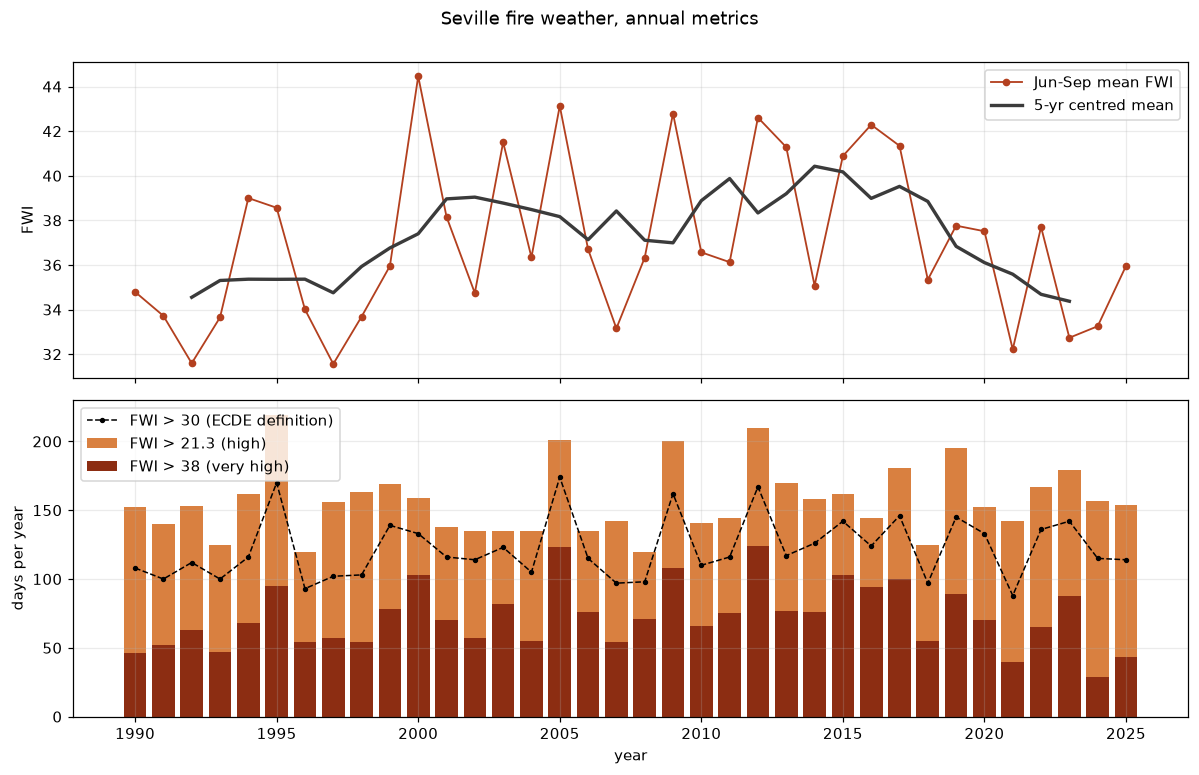

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(ann.index, ann.fwi_season_mean, "o-", lw=1.2, ms=4, color="#b3401f",
             label="Jun-Sep mean FWI")
axes[0].plot(ann.index, ann.fwi_season_mean.rolling(5, center=True).mean(),
             lw=2.2, color="#3b3b3b", label="5-yr centred mean")
axes[0].set_ylabel("FWI"); axes[0].legend()
axes[1].bar(ann.index, ann.days_high_effis, color="#d98040", label="FWI > 21.3 (high)")
axes[1].bar(ann.index, ann.days_very_high_effis, color="#8c2d12",
            label="FWI > 38 (very high)")
axes[1].plot(ann.index, ann.days_fwi_gt30, "k.--", lw=1, ms=5,
             label="FWI > 30 (ECDE definition)")
axes[1].set_ylabel("days per year"); axes[1].set_xlabel("year"); axes[1].legend()
fig.suptitle("Seville fire weather, annual metrics", y=1.00)
fig.tight_layout()

## 4. Seasonality and season length

The fire season is a result here, not an input. Jun–Sep is the EFFIS convention,
but the day-of-year climatology shows where Seville's danger window actually
sits, and whether it is widening.

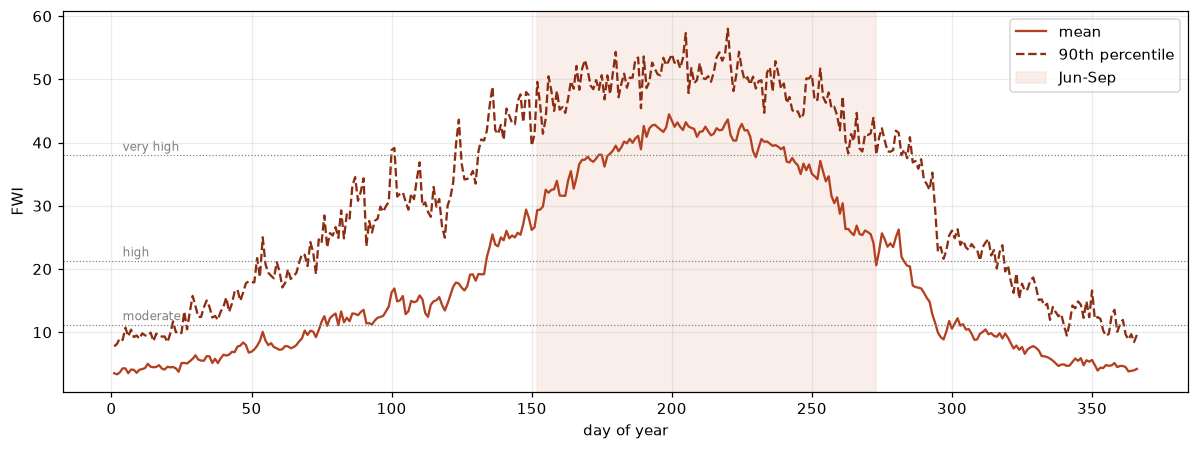

In [7]:
clim = f.groupby(f.index.dayofyear).agg(mean="mean", median="median",
                                        p90=lambda s: s.quantile(0.90))

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(clim.index, clim["mean"], color="#b3401f", label="mean")
ax.plot(clim.index, clim["p90"], color="#8c2d12", ls="--", label="90th percentile")
for name in ("moderate", "high", "very high"):
    ax.axhline(EFFIS[name], color="grey", lw=.8, ls=":")
    ax.text(4, EFFIS[name] + .7, name, fontsize=8, color="grey")
ax.axvspan(152, 273, color="#f0d0c0", alpha=.35, label="Jun-Sep")
ax.set_xlabel("day of year"); ax.set_ylabel("FWI"); ax.legend()
fig.tight_layout()

In [8]:
hi_days = f[f > EFFIS["high"]]
doy_by_year = hi_days.index.dayofyear.to_series(index=hi_days.index.year)
sb = pd.DataFrame({"first_high_doy": doy_by_year.groupby(level=0).min(),
                   "last_high_doy":  doy_by_year.groupby(level=0).max()})
sb.index.name = "year"
sb["high_season_span"] = sb.last_high_doy - sb.first_high_doy
sb = sb.loc[sb.index.isin(complete)]

print("high-danger season, decade means:")
print(sb.groupby((sb.index // 10) * 10).mean().round(1).to_string())
print()
print(trend_table(sb, ["first_high_doy", "last_high_doy", "high_season_span"]).round(3).to_string())

high-danger season, decade means:
      first_high_doy  last_high_doy  high_season_span
year                                                 
1990            74.7          299.0             224.3
2000            84.4          302.7             218.3
2010            77.1          304.9             227.8
2020            71.0          311.2             240.2

                   n  ols_per_decade  ols_p  ols_r2  theilsen_per_decade   ts_lo   ts_hi  kendall_tau  kendall_p  ts_excludes_zero  sign_agreement
metric                                                                                                                                            
first_high_doy    36          -2.448  0.645   0.006               -2.971 -14.000   9.500       -0.062      0.595             False            True
last_high_doy     36           5.188  0.167   0.055                5.553  -1.176  13.214        0.198      0.091             False            True
high_season_span  36           7.636  0.232   0.042  

`first_high_doy` shifting earlier and `last_high_doy` later are separate claims
with separate evidence — a widening span can come from either end, and which end
it is matters for anything operational.

## 5. Autocorrelation: how much data is actually here

This cell is the justification for everything in section 6. If the effective
sample size is a small fraction of the nominal one, ordinary correlation
*p*-values on daily data are not merely optimistic, they are meaningless.

daily FWI lag-1 autocorrelation : 0.925
nominal n                       : 13149
effective n (AR1 approximation) : 513  (3.9% of nominal)
first lag with |ACF| < 0.2      : >60 days


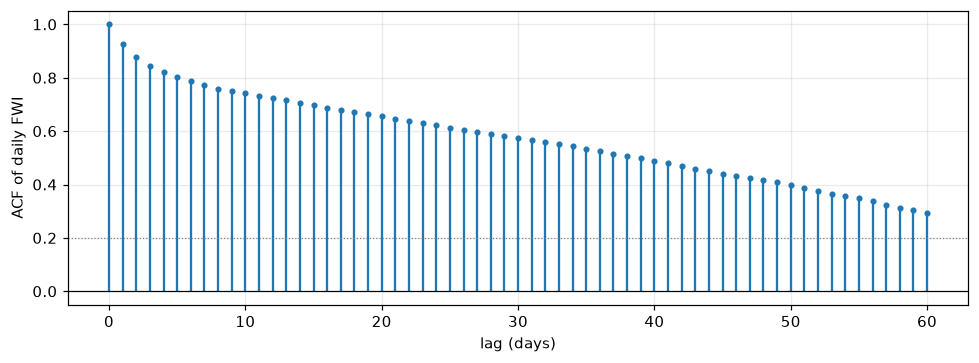

In [9]:
def acf(x, nlags=60):
    x = np.asarray(x, float); x = x - np.nanmean(x)
    den = np.nansum(x * x)
    return np.array([1.0] + [np.nansum(x[:-k] * x[k:]) / den for k in range(1, nlags + 1)])

a = acf(f.values, 60)
lag1 = a[1]
n_eff = len(f) * (1 - lag1) / (1 + lag1)
below = np.where(np.abs(a) < 0.2)[0]

print(f"daily FWI lag-1 autocorrelation : {lag1:.3f}")
print(f"nominal n                       : {len(f)}")
print(f"effective n (AR1 approximation) : {n_eff:.0f}  ({100*n_eff/len(f):.1f}% of nominal)")
print(f"first lag with |ACF| < 0.2      : "
      f"{int(below[0]) if len(below) else '>' + str(len(a)-1)} days")

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.stem(range(len(a)), a, basefmt=" ", markerfmt=".")
ax.axhline(0, color="k", lw=.8); ax.axhline(0.2, color="grey", ls=":", lw=.8)
ax.set_xlabel("lag (days)"); ax.set_ylabel("ACF of daily FWI")
fig.tight_layout()

In [10]:
def block_bootstrap_ci(x, y, block=30, n_boot=800, seed=0,
                       stat=lambda a, b: stats.spearmanr(a, b).statistic):
    """Moving-block bootstrap CI for a statistic on autocorrelated series.

    Resampling contiguous blocks preserves short-range dependence, so the
    interval reflects the number of *independent* stretches of data rather than
    the number of rows.
    """
    rng = np.random.default_rng(seed)
    x = np.asarray(x, float); y = np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    n = len(x)
    if n <= block:
        return np.nan, (np.nan, np.nan)
    nblocks = int(np.ceil(n / block))
    out = np.empty(n_boot)
    for i in range(n_boot):
        s = rng.integers(0, n - block + 1, nblocks)
        idx = np.concatenate([np.arange(j, j + block) for j in s])[:n]
        out[i] = stat(x[idx], y[idx])
    return stat(x, y), tuple(np.percentile(out, [2.5, 97.5]))

## 6. H2 — daily FWI against daily heat and dryness

This section needs a daily ERA5 CSV at `DATA / "seville_era5_daily.csv"` with a
`date` column plus whatever heat/dryness fields you derived. It skips cleanly if
the file is absent. Adjust `HEAT_COLS` to your column names.

The four framings below answer progressively harder questions, and the numbers
drop sharply as you go down the list. That decline *is* the finding:

1. **Full year, raw** — inflated. Both series share an annual cycle, so this
   mostly measures "summer is hot and also flammable".
2. **Jun–Sep only** — removes most of the seasonal co-movement.
3. **Day-of-year anomalies** — removes the climatology from both sides. This is
   the one that tests whether an *unusually* hot, dry day is an *unusually*
   dangerous one.
4. **Lagged** — separates same-day flammability (FFMC-like, hours) from
   antecedent drying (DC-like, weeks). If lagged terms beat lag 0, the mechanism
   is accumulated dryness, not today's heat.

In [11]:
HEAT_COLS = ["t2m_max", "rh_min", "tp_mm"]   # <-- edit to match your ERA5 CSV

if not ERA5_CSV.exists():
    print(f"[skip] no ERA5 daily CSV at {ERA5_CSV}")
    m = None
else:
    era = pd.read_csv(ERA5_CSV, parse_dates=["date"]).set_index("date")
    m = fwi.join(era, how="inner")
    HEAT = [c for c in HEAT_COLS if c in m]
    missing = set(HEAT_COLS) - set(HEAT)
    if missing:
        print(f"[warn] not in the ERA5 CSV, ignored: {sorted(missing)}")
    print(f"joined rows: {len(m)}   span {m.index.min().date()} .. {m.index.max().date()}")
    print(f"predictors: {HEAT}")

[skip] no ERA5 daily CSV at data\seville_era5_daily.csv


In [12]:
if m is not None:
    ms = m[(m.index.month >= FIRE_SEASON[0]) & (m.index.month <= FIRE_SEASON[1])]

    anom = m.copy()
    for col in HEAT + ["fire_weather_index"]:
        anom[col] = m[col] - m[col].groupby(m.index.dayofyear).transform("mean")
    anom_s = anom.loc[ms.index]

    rows = []
    for label, frame in [("full year, raw", m),
                         ("Jun-Sep, raw", ms),
                         ("Jun-Sep, day-of-year anomalies", anom_s)]:
        for col in HEAT:
            r, ci = block_bootstrap_ci(frame[col], frame["fire_weather_index"])
            rows.append({"framing": label, "predictor": col,
                         "spearman_rho": r, "ci_lo": ci[0], "ci_hi": ci[1],
                         "excludes_zero": (ci[0] > 0) or (ci[1] < 0)})
    corr = pd.DataFrame(rows).set_index(["framing", "predictor"])
    print(corr.round(3).to_string())

In [13]:
if m is not None:
    lags = range(0, 15)
    lag_tab = pd.DataFrame(
        {col: [stats.spearmanr(anom_s[col].shift(k), anom_s["fire_weather_index"],
                               nan_policy="omit").statistic for k in lags]
         for col in HEAT},
        index=pd.Index(lags, name="lag_days"))
    print(lag_tab.round(3).to_string())
    print("\npeak |rho| lag per predictor:")
    print(lag_tab.abs().idxmax().to_string())

    fig, ax = plt.subplots(figsize=(9, 3.6))
    for col in HEAT:
        ax.plot(lag_tab.index, lag_tab[col], "o-", ms=4, label=col)
    ax.axhline(0, color="k", lw=.8)
    ax.set_xlabel("predictor lag (days)"); ax.set_ylabel("Spearman rho vs FWI anomaly")
    ax.legend(); fig.tight_layout()

### Exceedance framing

A correlation coefficient is a poor summary of a threshold-driven hazard. The
question a fire service asks is *given a hot day, how much more likely is high
danger* — a conditional probability with a base rate attached, which is also far
easier to sanity-check than ρ.

In [14]:
if m is not None and "t2m_max" in m:
    hot_thr = m["t2m_max"].quantile(0.90)
    hot  = (m["t2m_max"] > hot_thr).rename("hot_p90")
    high = (m["fire_weather_index"] > EFFIS["high"]).rename("fwi_high")

    print(f"hot-day threshold (90th pct of t2m_max): {hot_thr:.1f}")
    print(pd.crosstab(hot, high).to_string())

    p_cond, p_base = high[hot].mean(), high.mean()
    print(f"\nP(high danger)            = {p_base:.3f}")
    print(f"P(high danger | hot day)  = {p_cond:.3f}")
    print(f"lift                      = {p_cond / max(p_base, 1e-9):.2f}x")

    # Same, restricted to the fire season, where the base rate is not diluted
    # by winter days that can never be dangerous.
    hs = hot.loc[ms.index]; hg = high.loc[ms.index]
    print(f"\nJun-Sep only: base = {hg.mean():.3f}, "
          f"conditional = {hg[hs].mean():.3f}, "
          f"lift = {hg[hs].mean() / max(hg.mean(), 1e-9):.2f}x")

The full-year lift is the number that will look impressive and mean least — it is
largely driven by the fact that hot days and dangerous days are both summer days.
The Jun–Sep lift is the one to quote.

## 7. ECDE annual cross-check — read the caveat first

If `data/seville_ecde_fire_annual_1990_2025.csv` exists, this compares the
ECDE annual counts against the CEMS daily data aggregated the same way. Treat
disagreement as expected and informative rather than as an error: per the ECDE
catalogue these are different products (EURO-CORDEX projections bias-corrected
over 1981–2010 vs ERA5-forced GEFF), on different native grids, and the ECDE FWI
is bias-corrected in mean and variance while the CEMS FWI is not.

Agreement here would not validate either series. Disagreement tells you the size
of the product difference, which is worth quantifying once and then citing.

In [15]:
if not ECDE_CSV.exists():
    print(f"[skip] no ECDE annual CSV at {ECDE_CSV}")
    print("run: python fetch_seville_fire.py ecde-check")
else:
    ecde = pd.read_csv(ECDE_CSV)
    j = ann.reset_index().merge(ecde, on="year", how="inner", suffixes=("", "_ecde"))
    print(f"overlapping complete years: {len(j)}")

    pairs = [("days_fwi_gt30", "days_with_high_fire_danger"),
             ("fwi_mean", "fire_weather_index")]
    for cems_col, ecde_col in pairs:
        if cems_col in j and ecde_col in j:
            r = stats.pearsonr(j[cems_col], j[ecde_col])
            diff = j[ecde_col] - j[cems_col]
            print(f"\n{ecde_col} (ECDE) vs {cems_col} (CEMS)")
            print(f"  pearson r = {r.statistic:+.3f}  (p={r.pvalue:.4f})")
            print(f"  mean bias = {diff.mean():+.2f}   sd of diff = {diff.std():.2f}")
            print(f"  ECDE mean = {j[ecde_col].mean():.2f}   "
                  f"CEMS mean = {j[cems_col].mean():.2f}")

[skip] no ECDE annual CSV at data\seville_ecde_fire_annual_1990_2025.csv
run: python fetch_seville_fire.py ecde-check


---

## What to write down before moving on

- Which FWI definition each reported number uses (season mean, > 30, EFFIS class).
- The effective sample size from section 5, next to any daily correlation.
- Whether the ECDE series was obtainable at all, and if so what its bias against
  CEMS is — so that any figure sourced from ECDE elsewhere in the project can be
  placed on the same footing.
- That FWI is noon-referenced, if any H2 predictor is a daily maximum.